20 米直线运动仿真（三级模式切换）
目标距离: 20.0 m

模式定义:
  长距离 (>5m):   v_max=1.5 m/s, decel=0.5 m, Kp_v=8.0
  中距离 (1~5m):  v_max=1.0 m/s, decel=0.3 m, Kp_v=5.0
  对接 (<1m):     v_max=0.5 m/s, decel=0.1 m, Kp_v=3.0
初始模式: 长距离
step=  0: mode=长距离, v_target=1.50, v_actual=0.00
step=  1: mode=长距离, v_target=1.50, v_actual=0.01
step=  2: mode=长距离, v_target=1.50, v_actual=0.03
step=  3: mode=长距离, v_target=1.50, v_actual=0.05
step=  4: mode=长距离, v_target=1.50, v_actual=0.07
step=  5: mode=长距离, v_target=1.50, v_actual=0.09
step=  6: mode=长距离, v_target=1.50, v_actual=0.11
step=  7: mode=长距离, v_target=1.50, v_actual=0.13
step=  8: mode=长距离, v_target=1.50, v_actual=0.15
step=  9: mode=长距离, v_target=1.50, v_actual=0.17
step= 10: mode=长距离, v_target=1.50, v_actual=0.19
step= 11: mode=长距离, v_target=1.50, v_actual=0.21
step= 12: mode=长距离, v_target=1.50, v_actual=0.23
step= 13: mode=长距离, v_target=1.50, v_actual=0.25
step= 14: mode=长距离, v_target=1.50, v_actual=0.27
step= 15: mode=长距离, v_target=1.50, v_actual=0.29
step= 16: 

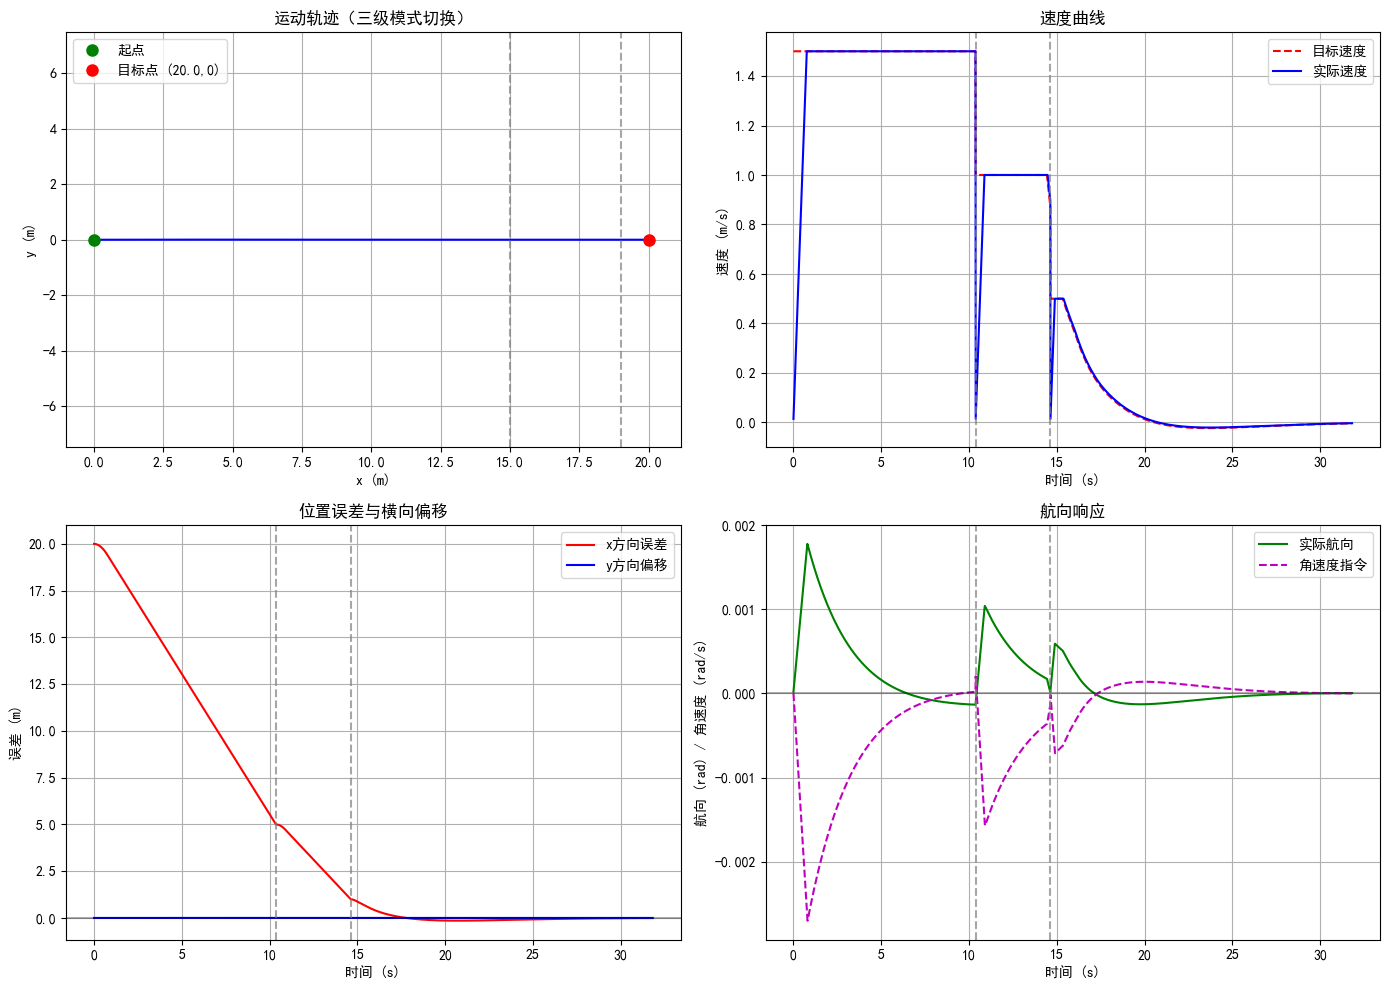


各阶段时间统计:
  长距离: 10.38s
  中距离: 4.26s
  对接: 17.18s


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

class RobotKinematics:
    def __init__(self, L=0.4, W=0.4, R=0.125):
        self.L, self.W, self.R = L, W, R
        self.a = L + W
        self.A = np.array([
            [1, -1, -self.a], [1, 1, self.a],
            [1, 1, -self.a], [1, -1, self.a]
        ])
        self.B = np.array([
            [1, 1, 1, 1], [-1, 1, 1, -1],
            [-1/self.a, 1/self.a, -1/self.a, 1/self.a]
        ])
    
    def inverse_kinematics(self, vx, vy, omega):
        return (1/self.R) * self.A @ np.array([vx, vy, omega])
    
    def forward_kinematics(self, wheel_speeds):
        return (self.R/4) * self.B @ wheel_speeds
    
    def update_pose(self, x, y, theta, vx, vy, omega, dt):
        R_mat = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
        v_world = R_mat @ np.array([vx, vy])
        return x + v_world[0]*dt, y + v_world[1]*dt, theta + omega*dt


class PID:
    def __init__(self, Kp, Ki, dt, limit=100.0):
        self.Kp, self.Ki, self.dt = Kp, Ki, dt
        self.integral, self.limit = 0, limit
    def update(self, target, actual):
        error = target - actual
        self.integral += error * self.dt
        self.integral = np.clip(self.integral, -self.limit, self.limit)
        return np.clip(self.Kp * error + self.Ki * self.integral, -100, 100)
    def reset(self):
        self.integral = 0


class Wheel:
    def __init__(self, m=200.0, R=0.125, mu=0.7, Ks=1, feq=0.05, i=15.0, amax=2.0):
        self.m = m
        self.R = R
        self.mu = mu
        self.Ks = Ks
        self.feq = feq
        self.i = i
        self.amax = amax
        self.speed = 0.0
        
    def update(self, torque, dt=0.01):
        F_raw = (self.i / self.R) * torque
        Fz = self.m * 9.8 / 4
        F_max = self.mu * Fz
        F_attach = np.clip(F_raw, -F_max, F_max)
        F_actual = self.Ks * F_attach
        a_linear_raw = F_actual / (self.m / 4)
        a_linear = np.clip(a_linear_raw, -self.amax, self.amax)
        alpha = a_linear / self.R
        self.speed += alpha * dt
        self.speed *= (1 - self.feq * dt)
        return self.speed
    
    def reset(self):
        self.speed = 0.0


class LowPassFilter:
    def __init__(self, fc, dt):
        wc = 2 * np.pi * fc
        self.alpha = wc * dt / (1 + wc * dt)
        self.value = 0
    def update(self, x):
        self.value = self.alpha * x + (1 - self.alpha) * self.value
        return self.value


class HeadingController:
    def __init__(self, Kp_theta, Ki_theta, dt, omega_max):
        self.Kp_theta = Kp_theta
        self.Ki_theta = Ki_theta
        self.dt = dt
        self.omega_max = omega_max
        self.integral = 0.0
    
    def update(self, theta_target, theta_actual):
        error = theta_target - theta_actual
        error = np.arctan2(np.sin(error), np.cos(error))
        self.integral += error * self.dt
        self.integral = np.clip(self.integral, -2.0, 2.0)
        omega = self.Kp_theta * error + self.Ki_theta * self.integral
        return np.clip(omega, -self.omega_max, self.omega_max)
    
    def reset(self):
        self.integral = 0.0


class PositionController:
    def __init__(self, Kp_x, Ki_x, Kp_y, dt, v_max, decel_distance=0.6, min_speed=0.1):
        self.Kp_x, self.Ki_x, self.Kp_y = Kp_x, Ki_x, Kp_y
        self.dt, self.v_max = dt, v_max
        self.decel_distance = decel_distance
        self.min_speed = min_speed
        self.integral_x = 0
        
    def update(self, x_target, x_actual, y_actual):
        error_x = x_target - x_actual
        remaining = max(0.01, x_target - x_actual)
        
        self.integral_x += error_x * self.dt
        self.integral_x = np.clip(self.integral_x, -1.0, 1.0)
        
        vx_base = self.Kp_x * error_x + self.Ki_x * self.integral_x
        
        if remaining < self.decel_distance:
            max_allowed = max(self.min_speed, self.v_max * (remaining / self.decel_distance))
            vx_target = np.clip(vx_base, -max_allowed, max_allowed)
        else:
            vx_target = np.clip(vx_base, -self.v_max, self.v_max)
        
        vy_target = -self.Kp_y * y_actual
        vy_target = np.clip(vy_target, -0.5, 0.5)
        
        return vx_target, vy_target
    
    def reset(self):
        self.integral_x = 0


def get_mode_params(remaining):
    if remaining > 5.0:
        # 长距离模式 (>5m)
        return {
            'Kp_v': 8.0, 'Ki_v': 1.0,
            'Kp_x': 0.7, 'Ki_x': 0.17,
            'Kp_theta': 1.5, 'Ki_theta': 0.05,
            'Kp_y': 0.6,
            'amax': 2.0,
            'omega_max': 1.2,
            'v_max': 1.5,
            'fc_wheel': 12,
            'decel_distance': 0.5,
            'min_speed': 0.15,
            'mode_name': '长距离'
        }
    elif remaining > 1.0:
        # 中距离模式 (1~5m)
        return {
            'Kp_v': 5.0, 'Ki_v': 0.8,
            'Kp_x': 0.7, 'Ki_x': 0.17,
            'Kp_theta': 1.5, 'Ki_theta': 0.05,
            'Kp_y': 0.6,
            'amax': 2.0,
            'omega_max': 1.0,
            'v_max': 1.0,
            'fc_wheel': 12,
            'decel_distance': 0.3,
            'min_speed': 0.12,
            'mode_name': '中距离'
        }
    else:
        # 对接模式 (<1m) - 优化版
        return {
            'Kp_v': 5.0, 'Ki_v': 0.8,      # 提高速度环响应
            'Kp_x': 0.6, 'Ki_x': 0.12,
            'Kp_theta': 1.2, 'Ki_theta': 0.04,
            'Kp_y': 0.5,
            'amax': 2.0,
            'omega_max': 0.8,
            'v_max': 0.5,
            'fc_wheel': 12,
            'decel_distance': 0.05,         # 减小减速距离
            'min_speed': 0.20,              # 提高最低速度
            'mode_name': '对接'
        }

def run_simulation_with_3mode(x_target, dt=0.01, max_steps=8000):
    kin = RobotKinematics()
    
    x, y, theta = 0, 0, 0
    v_actual = 0
    theta_target = 0
    
    traj, speed_trace, speed_cmd_trace = [], [], []
    error_x_trace, error_y_trace, theta_trace = [], [], []
    omega_cmd_trace = []
    mode_trace = []
    
    # 初始模式（长距离）
    params_current = get_mode_params(x_target - x)
    speed_pids = [PID(params_current['Kp_v'], params_current['Ki_v'], dt) for _ in range(4)]
    wheels = [Wheel(amax=params_current['amax']) for _ in range(4)]
    lpf = LowPassFilter(params_current['fc_wheel'], dt)
    pos_ctrl = PositionController(
        params_current['Kp_x'], params_current['Ki_x'], params_current['Kp_y'], 
        dt, params_current['v_max'], 
        params_current['decel_distance'],
        params_current['min_speed']
    )
    heading_ctrl = HeadingController(params_current['Kp_theta'], params_current['Ki_theta'], dt, params_current['omega_max'])
    
    current_mode = params_current['mode_name']
    print(f"初始模式: {current_mode}")
    
    for step in range(max_steps):
        remaining = x_target - x
        
        # 检查是否需要切换模式
        new_params = get_mode_params(remaining)
        if new_params['mode_name'] != current_mode:
            print(f"\n模式切换: {current_mode} → {new_params['mode_name']} (剩余距离={remaining:.3f}m)")
            current_mode = new_params['mode_name']
            params_current = new_params
            
            # 重新初始化控制器
            speed_pids = [PID(params_current['Kp_v'], params_current['Ki_v'], dt) for _ in range(4)]
            wheels = [Wheel(amax=params_current['amax']) for _ in range(4)]
            lpf = LowPassFilter(params_current['fc_wheel'], dt)
            pos_ctrl = PositionController(
                params_current['Kp_x'], params_current['Ki_x'], params_current['Kp_y'], 
                dt, params_current['v_max'], 
                params_current['decel_distance'],
                params_current['min_speed']
            )
            heading_ctrl = HeadingController(params_current['Kp_theta'], params_current['Ki_theta'], dt, params_current['omega_max'])
        
        vx_target, vy_target = pos_ctrl.update(x_target, x, y)
        omega_cmd = heading_ctrl.update(theta_target, theta)
        omega_cmd_trace.append(omega_cmd)
        
        wheels_target = kin.inverse_kinematics(vx_target, vy_target, omega_cmd)
        torque = np.array([speed_pids[i].update(wheels_target[i], wheels[i].speed) for i in range(4)])
        
        if step < 30:
            print(f"step={step:3d}: mode={current_mode}, v_target={vx_target:.2f}, v_actual={v_actual:.2f}")
        
        wheels_actual = np.array([wheels[i].update(torque[i], dt) for i in range(4)])
        wheels_filtered = np.array([lpf.update(w) for w in wheels_actual])
        v_body = kin.forward_kinematics(wheels_filtered)
        
        v_body[0] = np.clip(v_body[0], -params_current['v_max'], params_current['v_max'])  # 速度限幅
        
        v_actual = v_body[0]
        
        x, y, theta = kin.update_pose(x, y, theta, v_body[0], v_body[1], v_body[2], dt)
        theta = np.arctan2(np.sin(theta), np.cos(theta))
        
        traj.append([x, y])
        speed_trace.append(v_body[0])
        speed_cmd_trace.append(vx_target)
        error_x_trace.append(x_target - x)
        error_y_trace.append(y)
        theta_trace.append(theta)
        mode_trace.append(current_mode)
        
        if abs(x_target - x) < 0.005 and abs(v_body[0]) < 0.02:
            break
    
    return {
        'traj': np.array(traj), 
        'speed': np.array(speed_trace),
        'speed_cmd': np.array(speed_cmd_trace),
        'error_x': np.array(error_x_trace), 
        'error_y': np.array(error_y_trace),
        'theta': np.array(theta_trace),
        'omega_cmd': np.array(omega_cmd_trace),
        'mode': mode_trace,
        'final_x': x, 
        'final_y': y, 
        'final_theta': theta,
        'steps': step, 
        'dt': dt
    }


# ==================== 20 米直线运动（三级模式切换） ====================
x_target = 20.0

print("=" * 60)
print("20 米直线运动仿真（三级模式切换）")
print("=" * 60)
print(f"目标距离: {x_target} m")
print("\n模式定义:")
print("  长距离 (>5m):   v_max=1.5 m/s, decel=0.5 m, Kp_v=8.0")
print("  中距离 (1~5m):  v_max=1.0 m/s, decel=0.3 m, Kp_v=5.0")
print("  对接 (<1m):     v_max=0.5 m/s, decel=0.1 m, Kp_v=3.0")

# 运行仿真
results = run_simulation_with_3mode(x_target)

time = np.arange(len(results['speed'])) * results['dt']

print(f"\n仿真结果:")
print(f"  终点位置: x={results['final_x']:.3f}m, y={results['final_y']:.3f}m")
print(f"  X方向误差: {abs(results['final_x'] - x_target):.4f}m")
print(f"  Y方向偏移: {results['final_y']:.4f}m")
print(f"  仿真时间: {results['steps'] * results['dt']:.2f}s")
print(f"  最大速度: {results['speed'].max():.3f} m/s")
print(f"  最终速度: {results['speed'][-1]:.3f} m/s")
print(f"  平均速度: {x_target / (results['steps'] * results['dt']):.2f} m/s")

# ==================== 绘图 ====================
plt.figure(figsize=(14, 10))

# 模式颜色映射
mode_colors = {'长距离': 'green', '中距离': 'orange', '对接': 'red'}

# 轨迹
plt.subplot(2, 2, 1)
plt.plot(results['traj'][:, 0], results['traj'][:, 1], 'b-', linewidth=1.5)
# 根据模式标记轨迹颜色
for i in range(1, len(results['traj'])):
    if results['mode'][i] != results['mode'][i-1]:
        plt.axvline(x=results['traj'][i, 0], color='gray', linestyle='--', alpha=0.7)
plt.plot(0, 0, 'go', markersize=8, label='起点')
plt.plot(x_target, 0, 'ro', markersize=8, label=f'目标点 ({x_target},0)')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('运动轨迹（三级模式切换）')
plt.legend()
plt.grid(True)
plt.axis('equal')

# 速度曲线（带模式背景）
plt.subplot(2, 2, 2)
plt.plot(time, results['speed_cmd'], 'r--', linewidth=1.5, label='目标速度')
plt.plot(time, results['speed'], 'b-', linewidth=1.5, label='实际速度')
# 标记模式切换点
for i in range(1, len(results['mode'])):
    if results['mode'][i] != results['mode'][i-1]:
        plt.axvline(x=time[i], color='gray', linestyle='--', alpha=0.7)
plt.xlabel('时间 (s)')
plt.ylabel('速度 (m/s)')
plt.title('速度曲线')
plt.legend()
plt.grid(True)

# 位置误差
plt.subplot(2, 2, 3)
plt.plot(time, results['error_x'], 'r-', linewidth=1.5, label='x方向误差')
plt.plot(time, results['error_y'], 'b-', linewidth=1.5, label='y方向偏移')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
for i in range(1, len(results['mode'])):
    if results['mode'][i] != results['mode'][i-1]:
        plt.axvline(x=time[i], color='gray', linestyle='--', alpha=0.7)
plt.xlabel('时间 (s)')
plt.ylabel('误差 (m)')
plt.title('位置误差与横向偏移')
plt.legend()
plt.grid(True)

# 航向响应
plt.subplot(2, 2, 4)
plt.plot(time, results['theta'], 'g-', linewidth=1.5, label='实际航向')
plt.plot(time, results['omega_cmd'], 'm--', linewidth=1.5, label='角速度指令')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
for i in range(1, len(results['mode'])):
    if results['mode'][i] != results['mode'][i-1]:
        plt.axvline(x=time[i], color='gray', linestyle='--', alpha=0.7)
plt.xlabel('时间 (s)')
plt.ylabel('航向 (rad) / 角速度 (rad/s)')
plt.title('航向响应')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 输出各阶段时间
print("\n各阶段时间统计:")
time_arr = time
mode_arr = results['mode']
current_mode = mode_arr[0]
start_time = 0
for i in range(1, len(mode_arr)):
    if mode_arr[i] != current_mode:
        duration = time_arr[i] - start_time
        print(f"  {current_mode}: {duration:.2f}s")
        current_mode = mode_arr[i]
        start_time = time_arr[i]
# 最后一段
duration = time_arr[-1] - start_time
print(f"  {current_mode}: {duration:.2f}s")